In [1]:
import torch
from SimPEG.config import SimpegConfig
# SimPEG functionality
from SimPEG import maps, data
from SimPEG.utils import model_builder
from SimPEG.electromagnetics.static import resistivity as dc
from SimPEG.electromagnetics.static.utils.static_utils import (
    generate_dcip_sources_line,
    pseudo_locations,
    plot_pseudosection,
    apparent_resistivity_from_voltage,
    convert_survey_3d_to_2d_lines,
)
from SimPEG import (
    maps,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)
try:
    import plotly
    from SimPEG.electromagnetics.static.utils.static_utils import plot_3d_pseudosection
    from IPython.core.display import display, HTML

    has_plotly = True
except ImportError:
    has_plotly = False
    pass

# discretize functionality
from discretize import TreeMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils.results_inversion import SaveInversionProgress
mpl.rcParams.update({"font.size": 14})

write_output = False  # Optional


In [2]:
x_topo, y_topo = np.meshgrid(
    np.linspace(-2100, 2100, 141), np.linspace(-2100, 2100, 141)
)
z_topo = 410.0 + 140.0 * (1 / np.pi) * (
    np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) - 400.0) / 200.0)
    - np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) + 400.0) / 200.0)
)

x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]


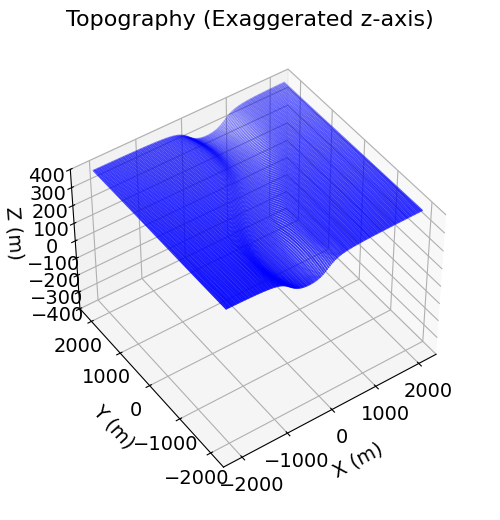

In [3]:
# Plot the topography
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.25, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)


In [4]:
# Define the parameters for each survey line
survey_type = "dipole-dipole"
data_type = "volt"
dimension_type = "3D"
end_locations_list = [
    np.r_[-1000.0, 1000.0, 0.0, 0.0],
    np.r_[-600.0, -600.0, -1000.0, 1000.0],
    np.r_[-300.0, -300.0, -1000.0, 1000.0],
    np.r_[0.0, 0.0, -1000.0, 1000.0],
    np.r_[300.0, 300.0, -1000.0, 1000.0],
    np.r_[600.0, 600.0, -1000.0, 1000.0],
]  # [x0, x1, y0, y1]
station_separation = 100.0 # separation
num_rx_per_src = 8 # N-lines

# The source lists for each line can be appended to create the source
# list for the whole survey.
source_list = []
for ii in range(0, len(end_locations_list)):
    source_list += generate_dcip_sources_line(
        survey_type,
        data_type,
        dimension_type,
        end_locations_list[ii],
        topo_xyz,
        num_rx_per_src,
        station_separation,
    )

# Define the survey
survey = dc.survey.Survey(source_list)


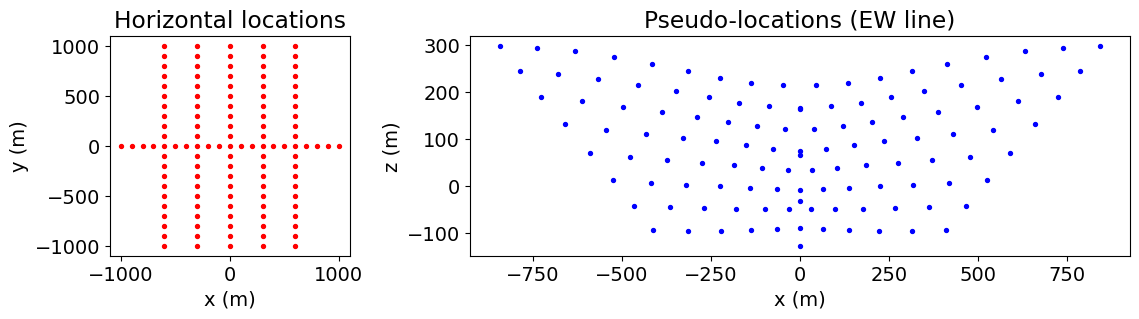

In [5]:
unique_locations = survey.unique_electrode_locations
fig = plt.figure(figsize=(12, 2.75))
ax1 = fig.add_axes([0.1, 0.1, 0.2, 0.8])
ax1.scatter(unique_locations[:, 0], unique_locations[:, 1], 8, "r")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.set_title("Horizontal locations")

pseudo_locations_xyz = pseudo_locations(survey)
inds = pseudo_locations_xyz[:, 1] == 0.0
ax2 = fig.add_axes([0.4, 0.1, 0.55, 0.8])
ax2.scatter(pseudo_locations_xyz[inds, 0], pseudo_locations_xyz[inds, -1], 8, "b")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("z (m)")
ax2.set_title("Pseudo-locations (EW line)")
plt.show()


In [6]:
# Defining domain size and minimum cell size
dh = 25.0  # base cell width
dom_width_x = 8000.0  # domain width x
dom_width_y = 8000.0  # domain width y
dom_width_z = 4000.0  # domain width z

# Number of base mesh cells in each direction. Must be a power of 2
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcy = 2 ** int(np.round(np.log(dom_width_y / dh) / np.log(2.0)))  # num. base cells y
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh
hx = [(dh, nbcx)]
hy = [(dh, nbcy)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hy, hz], x0="CCN", diagonal_balance=True)

# Shift top to maximum topography
mesh.origin = mesh.origin + np.r_[0.0, 0.0, z_topo.max()]

# Mesh refinement based on surface topography
k = np.sqrt(np.sum(topo_xyz[:, 0:2] ** 2, axis=1)) < 1200
mesh.refine_surface(topo_xyz[k, :], padding_cells_by_level=[0, 4, 4], finalize=False)

# Mesh refinement near electrodes.
mesh.refine_points(unique_locations, padding_cells_by_level=[6, 6, 4], finalize=False)

# Finalize the mesh
mesh.finalize()


In [7]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

# number of active cells
n_active = np.sum(active_cells)


In [8]:
# Define conductivity values in S/m (take reciprocal for resistivities in Ohm m)
air_conductivity = 1e-8
background_conductivity = 1e-2
conductor_conductivity = 1e-1
resistor_conductivity = 1e-3


In [9]:
# Define conductivity model
conductivity_model = background_conductivity * np.ones(n_active)

ind_conductor = model_builder.get_indices_sphere(
    np.r_[-300.0, 0.0, 100.0], 165.0, mesh.cell_centers[active_cells, :]
)
conductivity_model[ind_conductor] = conductor_conductivity

ind_resistor = model_builder.get_indices_sphere(
    np.r_[300.0, 0.0, 100.0], 165.0, mesh.cell_centers[active_cells, :]
)
conductivity_model[ind_resistor] = resistor_conductivity

# Define log-resistivity model
resistivity_model = 1 / conductivity_model
log_resistivity_model = np.log(resistivity_model)


In [10]:
# Conductivity map. Model parameters are conductivities for all active cells.
conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity)

# Resistivity map. Model parameters are log-resistivities for all active cells.
log_resistivity_map = maps.InjectActiveCells(
    mesh, active_cells, 1 / air_conductivity
) * maps.ExpMap(nP=n_active)


In [11]:
# Generate a mapping to ignore inactice cells in plot
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)


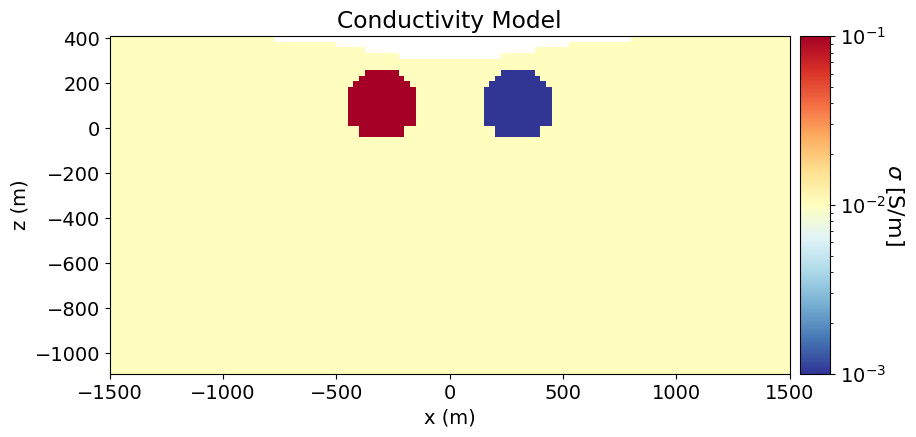

In [12]:
fig = plt.figure(figsize=(10, 4.5))

norm = LogNorm(vmin=1e-3, vmax=1e-1)

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    plotting_map * conductivity_model,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title("Conductivity Model")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([-1500, 1500])
ax1.set_ylim([z_topo.max() - 1500, z_topo.max()])

ax2 = fig.add_axes([0.84, 0.15, 0.03, 0.75])
cbar = mpl.colorbar.ColorbarBase(
    ax2, cmap=mpl.cm.RdYlBu_r, norm=norm, orientation="vertical"
)
cbar.set_label(r"$\sigma$ [S/m]", rotation=270, labelpad=15, size=16)


In [13]:
survey.drape_electrodes_on_topography(mesh, active_cells, option="top")


In [14]:
def forward_torch(m, dtype="rho"):
    cfg = SimpegConfig()
    cfg.torch_is_active = True
    cfg.device = 'cpu'
    cfg.dtype = torch.float64
    cfg.solver = "pardiso"

    simulation_res = dc.simulation.Simulation3DNodal(
    mesh, survey=survey, rhoMap=log_resistivity_map)
    M = torch.log(m)
    dc_data = simulation_res.make_synthetic_data(M, relative_error=0)
    if dtype == "rho":
        dobs = apparent_resistivity_from_voltage(survey, dc_data.dobs)
    else:
        dobs = dc_data.dobs
    return dobs

def forward_vanilla(model, dtype="rho"):
    cfg = SimpegConfig()
    cfg.torch_is_active = False
    simulation_res = dc.simulation.Simulation3DNodal(mesh, survey=survey, rhoMap=log_resistivity_map)
    dc_data = simulation_res.make_synthetic_data(model, relative_error=0)
    if dtype == "rho":
        dobs = apparent_resistivity_from_voltage(survey, dc_data.dobs)
    return dobs, simulation_res


In [15]:
simulation_vanilla_res = forward_vanilla(log_resistivity_model)[1]


In [16]:
m_true = torch.tensor(np.exp(log_resistivity_model), requires_grad=True)
dobs = forward_torch(m_true)
loss=dobs.sum()
loss.backward()
J_aggregated_torch = m_true.grad.detach().numpy()


c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\maps.py:3172: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  indices = torch.tensor(
c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\electromagnetics\static\resistivity\simulation.py:644: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  A = torch.sparse.mm(torch.sparse.mm(Grad.T, MeSigma), Grad)


In [17]:
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)
cfg = SimpegConfig()
cfg.torch_is_active = False


In [18]:
fields = simulation_vanilla_res.fields(log_resistivity_model)
J_full_vanilla = simulation_vanilla_res._Jtvec(log_resistivity_model, f=fields)
J_aggregated_vanilla = abs(J_full_vanilla.sum(axis=1))


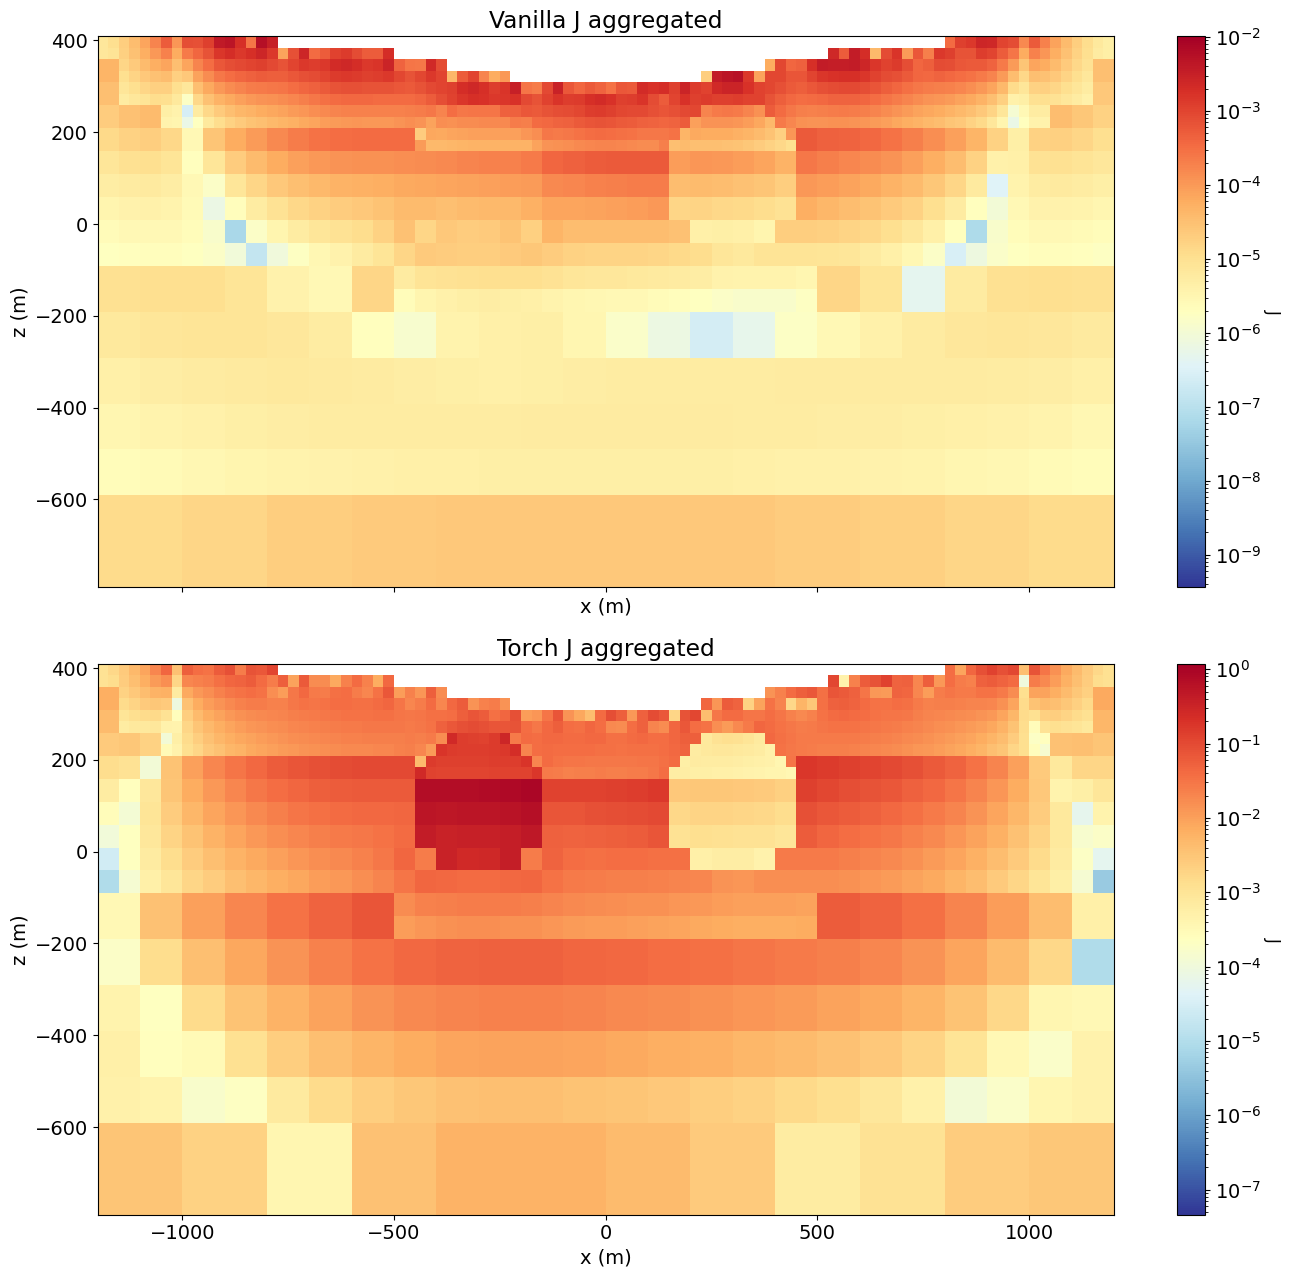

In [27]:
fig, ax = plt.subplots(2,1,figsize=(14, 13), sharex=True)

norm_vanilla = LogNorm(vmin=J_aggregated_vanilla.min(), vmax=J_aggregated_vanilla.max())
norm_torch = LogNorm(vmin=abs(J_aggregated_torch).min(), vmax=abs(J_aggregated_torch).max())

J_aggregate = [J_aggregated_vanilla, abs(J_aggregated_torch)]
norm =[norm_vanilla, norm_torch]
title_J_plots = ["Vanilla J aggregated", "Torch J aggregated"]

for idx, J in enumerate(J_aggregate):
    
    im = mesh.plot_slice(
        plotting_map * J,
        ax=ax[idx],
        normal="Y",
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm[idx]},
    )
    ax[idx].set_title(title_J_plots[idx])
    ax[idx].set_xlim([-1200, 1200])
    ax[idx].set_ylim([topo_xyz[:, -1].max() - 1200, topo_xyz[:, -1].max()])
    ax[idx].set_xlabel("x (m)")
    ax[idx].set_ylabel("z (m)")

    # agregar la barra de color a la derecha de cada subplot
    cbar = fig.colorbar(im[0], ax=ax[idx], orientation="vertical")
    cbar.set_label("J", rotation=270, labelpad=15, size=12)

plt.tight_layout()
